# Nordic global weekly EDA
Utforskar datan för de nordiska länderna.

In [39]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

# Läs in datat
DATA_PATH = Path("../../data/processed")
df = pd.read_csv(DATA_PATH / "nordic_global_weekly.csv", sep=';', encoding='utf-8')
duckdb.register("nordic_weekly", df)

# Stil för matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

### Skapar querys och tar hjälp av duckdb

1. Hitta landet med högst andel film/tv-serie tittare

In [40]:
# Med country_name och category kan vi analysera fördelningen av film/tv-serier i topp 10 per land
query = """
    SELECT 
        country_name,
        category,
        SUM(cumulative_weeks_in_top_10) AS total_weeks
    FROM nordic_weekly
    WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY country_name, category
    ORDER BY country_name, category
"""
result = duckdb.sql(query).df()
print("=== Fördelning film/TV per land ===\n")
for country in result['country_name'].unique():
    country_data = result[result['country_name'] == country]
    film_weeks = country_data[country_data['category']=='Films']['total_weeks'].values[0]
    tv_weeks = country_data[country_data['category']=='TV']['total_weeks'].values[0]
    total = film_weeks + tv_weeks
    print(f"{country}: Film {film_weeks} veckor ({film_weeks/total:.0%}), TV {tv_weeks} veckor ({tv_weeks/total:.0%})")

# Använder duckdb för att räkna ut vilken andel av veckorna i topp 10 som är film vs TV per land
film_pct = []
for country in result['country_name'].unique():
    country_data = result[result['country_name'] == country]
    film_weeks = country_data[country_data['category']=='Films']['total_weeks'].values[0]
    tv_weeks = country_data[country_data['category']=='TV']['total_weeks'].values[0]
    film_pct.append((country, film_weeks/(film_weeks+tv_weeks)))
film_winner = max(film_pct, key=lambda x: x[1])
print(f"\n🍿 {film_winner[0]} har högst andel filmtittande ({film_winner[1]:.0%})")

=== Fördelning film/TV per land ===

Denmark: Film 6372.0 veckor (45%), TV 7647.0 veckor (55%)
Finland: Film 5872.0 veckor (44%), TV 7392.0 veckor (56%)
Iceland: Film 7805.0 veckor (52%), TV 7085.0 veckor (48%)
Norway: Film 6243.0 veckor (44%), TV 7810.0 veckor (56%)
Sweden: Film 6237.0 veckor (45%), TV 7733.0 veckor (55%)

🍿 Iceland har högst andel filmtittande (52%)


2. Kolla hur många gemensamma titlar Sverige och Danmark har

In [41]:
# Använder show_title och INTERSECT för att hitta gemensamma titlar i både Sveriges och Danmarks topplistor
query = """
    WITH se_titles AS (
        SELECT DISTINCT show_title
        FROM nordic_weekly
        WHERE country_name = 'Sweden'
    ),
    dk_titles AS (
        SELECT DISTINCT show_title
        FROM nordic_weekly
        WHERE country_name = 'Denmark'
    )
    SELECT show_title
    FROM se_titles
    INTERSECT
    SELECT show_title
    FROM dk_titles
    ORDER BY show_title
    LIMIT 15
"""
common_titles = duckdb.sql(query).df()
print("=== Gemensamma titlar i både Sveriges och Danmarks topplistor ===\n")
for title in common_titles['show_title']:
    print(f"• {title}")
print("\nVisar 15 av många titlar")

# Räkna hur många gemensamma
count = duckdb.sql("""
    SELECT COUNT(*) AS common_count FROM (
        SELECT show_title FROM nordic_weekly WHERE country_name='Sweden'  
        INTERSECT
        SELECT show_title FROM nordic_weekly WHERE country_name='Denmark'
    )
""").df().iloc[0,0]
print(f"\nTotalt {count} titlar förekommer i båda länderna.")

=== Gemensamma titlar i både Sveriges och Danmarks topplistor ===

• 12 Mighty Orphans
• 12 Strong
• 13 Hours: The Secret Soldiers of Benghazi
• 14 Peaks: Nothing Is Impossible
• 1883
• 1899
• 1917
• 1992
• 2 Hearts
• 21
• 21 Jump Street
• 27 Dresses
• 28 Days
• 3 Body Problem
• 365 Days

Visar 15 av många titlar

Totalt 1513 titlar förekommer i båda länderna.


3. Filmer/TV-serier som bara finns i ett nordiskt land

In [42]:
# Titlar som förekommer i endast ett nordiskt land
query = """
    WITH title_country AS (
        SELECT DISTINCT show_title, country_name
        FROM nordic_weekly
        WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    ),
    title_counts AS (
        SELECT show_title, COUNT(*) AS country_count,
               STRING_AGG(country_name, ', ') AS countries
        FROM title_country
        GROUP BY show_title
    )
    SELECT show_title, countries
    FROM title_counts
    WHERE country_count = 1
    ORDER BY show_title
    LIMIT 10
"""
unique_titles = duckdb.sql(query).df()
print("=== Exempel på titlar som bara dyker upp i ett nordiskt land ===\n")
for _, row in unique_titles.iterrows():
    print(f"'{row['show_title']}' - endast i {row['countries']}")

=== Exempel på titlar som bara dyker upp i ett nordiskt land ===

'10 Cloverfield Lane' - endast i Finland
'10x10' - endast i Iceland
'13 Going on 30' - endast i Iceland
'13 Hours that Saved Britain' - endast i Finland
'1670' - endast i Iceland
'22 Jump Street' - endast i Iceland
'3000 Miles to Graceland' - endast i Iceland
'438 dagar' - endast i Sweden
'7 Women and a Murder' - endast i Finland
'900 Days Without Anabel' - endast i Iceland


4. Top filmer/tv-serier som hållt sig längst i topp 10

In [43]:
# Titlar som hållit sig kvar i topp 10 längst (>=10 veckor)
query = """
    SELECT 
        country_name,
        show_title,
        category,
        MAX(cumulative_weeks_in_top_10) AS total_weeks
    FROM nordic_weekly
    WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY country_name, show_title, category
    HAVING MAX(cumulative_weeks_in_top_10) >= 10
    ORDER BY total_weeks DESC
    LIMIT 10
"""
long_running = duckdb.sql(query).df()
print("=== Titlar som hållit sig kvar i topp 10 längst (>=10 veckor) ===\n")
for _, row in long_running.iterrows():
    print(f"{row['country_name']}: '{row['show_title']}' ({row['category']}) – {row['total_weeks']} veckor")
    
# Hitta den allra längsta
top = long_running.iloc[0]
print(f"\n🏆 Längsta löparen: '{top['show_title']}' i {top['country_name']} med {top['total_weeks']} veckor!")

=== Titlar som hållit sig kvar i topp 10 längst (>=10 veckor) ===

Iceland: 'Paw Patrol: The Movie' (Films) – 48 veckor
Sweden: 'KPop Demon Hunters' (Films) – 36 veckor
Denmark: 'KPop Demon Hunters' (Films) – 36 veckor
Finland: 'Paw Patrol: The Movie' (Films) – 35 veckor
Denmark: 'Paw Patrol: The Movie' (Films) – 35 veckor
Sweden: 'Paw Patrol: The Movie' (Films) – 32 veckor
Norway: 'KPop Demon Hunters' (Films) – 31 veckor
Norway: 'Paw Patrol: The Movie' (Films) – 30 veckor
Finland: 'KPop Demon Hunters' (Films) – 30 veckor
Iceland: 'KPop Demon Hunters' (Films) – 27 veckor

🏆 Längsta löparen: 'Paw Patrol: The Movie' i Iceland med 48 veckor!


5. Hur många veckor länder har filmer/tv-serier som ligger i topp 10
* Landet som har flest veckor vinner

In [44]:
query = """
    SELECT 
        country_name,
        SUM(cumulative_weeks_in_top_10) AS total_weeks,
        COUNT(DISTINCT show_title) AS unique_titles
    FROM nordic_weekly
    WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY country_name
    ORDER BY total_weeks DESC
"""
result = duckdb.sql(query).df()
print("=== Antal veckor i topp 10 per land ===\n")
for _, row in result.iterrows():
    print(f"{row['country_name']}: {row['total_weeks']} veckor, {row['unique_titles']} unika titlar")

# Vem har flest veckor i topp 10 totalt?
winner = result.iloc[0]['country_name']
print(f"\n🏆 {winner} har flest veckor i topp 10 totalt!")

=== Antal veckor i topp 10 per land ===

Iceland: 14890.0 veckor, 1640 unika titlar
Norway: 14053.0 veckor, 1658 unika titlar
Denmark: 14019.0 veckor, 1675 unika titlar
Sweden: 13970.0 veckor, 1697 unika titlar
Finland: 13264.0 veckor, 1742 unika titlar

🏆 Iceland har flest veckor i topp 10 totalt!


6. Vilken månad som har filmer/tv-serier som legat i topp 10 i flest veckor
* Hur många veckor har december?

In [45]:
# Konverterar week till datum först, sedan extraherar månad och räknar antal veckor i topp 10 per månad
query = """
    SELECT 
        EXTRACT(MONTH FROM CAST(week AS DATE)) AS month,
        COUNT(*) AS antal_veckor_i_topp10,
        COUNT(DISTINCT show_title) AS unika_titlar
    FROM nordic_weekly
    WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY EXTRACT(MONTH FROM CAST(week AS DATE))
    ORDER BY month
"""
seasonal = duckdb.sql(query).df()
print("=== Aktivitetsnivå per månad ===\n")
month_names = ['Jan','Feb','Mar','Apr','Maj','Jun','Jul','Aug','Sep','Okt','Nov','Dec']
max_month = seasonal.loc[seasonal['antal_veckor_i_topp10'].idxmax()]
print(f"{month_names[int(max_month['month'])-1]} har flest veckor i topp 10 ({max_month['antal_veckor_i_topp10']} veckor)")
min_month = seasonal.loc[seasonal['antal_veckor_i_topp10'].idxmin()]
print(f"{month_names[int(min_month['month'])-1]} har minst aktivitet ({min_month['antal_veckor_i_topp10']} veckor)")

# Julspecial!
dec = seasonal[seasonal['month']==12]
if not dec.empty:
    print(f"\n🎄 December har {dec['antal_veckor_i_topp10'].values[0]} veckor i topp 10 – mycket julmys!")

=== Aktivitetsnivå per månad ===

Okt har flest veckor i topp 10 (2300 veckor)
Apr har minst aktivitet (1700 veckor)

🎄 December har 2200 veckor i topp 10 – mycket julmys!


### Visualisera querys i grafer och diagram

1. De 5 filmer som legat i topp 10 per veckor

Topp 5 filmer i Norden:
                       show_title  total_weeks
0           Paw Patrol: The Movie       3429.0
1              KPop Demon Hunters       2671.0
2                     The Holiday        682.0
3  How the Grinch Stole Christmas        629.0
4                 Despicable Me 3        436.0


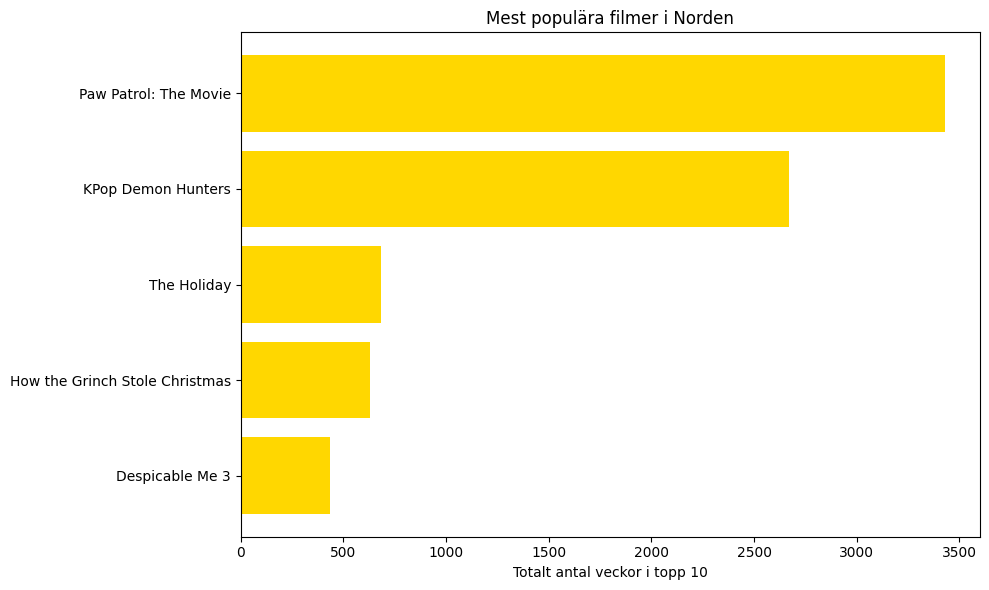

In [46]:
#Summerar cumulative_weeks för varje film över alla nordiska länder
query = """
    SELECT 
        show_title,
        SUM(cumulative_weeks_in_top_10) AS total_weeks
    FROM nordic_weekly
    WHERE category = 'Films'
      AND country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY show_title
    ORDER BY total_weeks DESC
    LIMIT 5
"""
top_films = duckdb.sql(query).df()
print("Topp 5 filmer i Norden:")
print(top_films)

plt.barh(top_films['show_title'], top_films['total_weeks'], color='gold')
plt.xlabel('Totalt antal veckor i topp 10')
plt.title('Mest populära filmer i Norden')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. Vad är bäst, filmer eller tv-serier, vad tycker de nordiska länderna?

  country_name category  avg_weeks
0      Denmark    Films   2.590244
1      Denmark       TV   3.108537
2      Finland    Films   2.386992
3      Finland       TV   3.004878
4      Iceland    Films   3.172764
5      Iceland       TV   2.880081
6       Norway    Films   2.537805
7       Norway       TV   3.174797
8       Sweden    Films   2.535366
9       Sweden       TV   3.143496


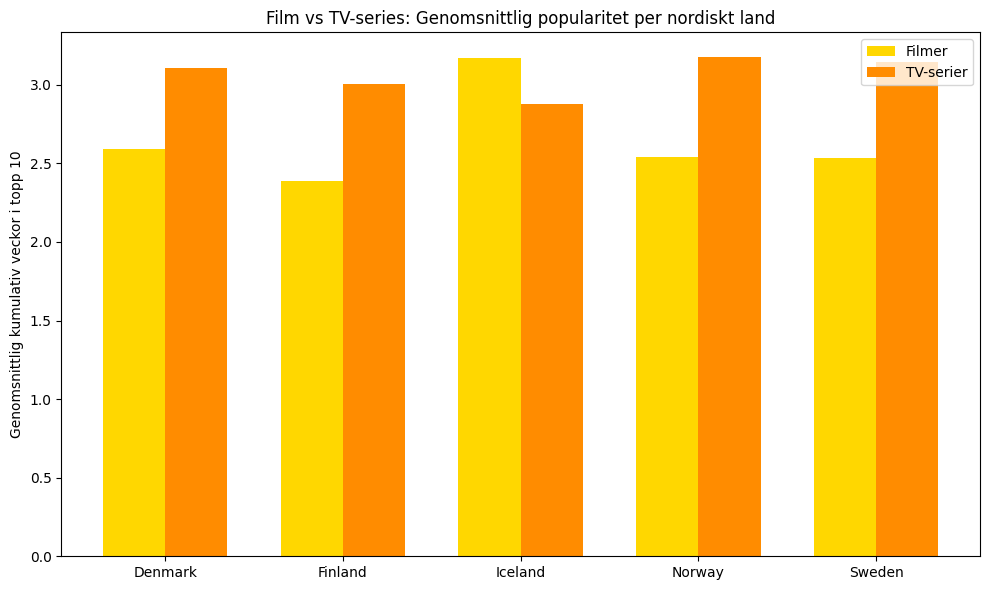

In [47]:
# Genomsnittlig kumulativ veckor i topp 10 per land och kategori
query = """
    SELECT 
        country_name,
        category,
        AVG(cumulative_weeks_in_top_10) AS avg_weeks
    FROM nordic_weekly
    WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY country_name, category
    ORDER BY country_name, category
"""
avg_by_country = duckdb.sql(query).df()
print(avg_by_country)

countries = avg_by_country['country_name'].unique()
categories = ['Films', 'TV']
x = range(len(countries))
width = 0.35

fig, ax = plt.subplots()
film_vals = avg_by_country[avg_by_country['category']=='Films']['avg_weeks'].values
tv_vals = avg_by_country[avg_by_country['category']=='TV']['avg_weeks'].values

bars1 = ax.bar([i - width/2 for i in x], film_vals, width, label='Filmer', color='gold')
bars2 = ax.bar([i + width/2 for i in x], tv_vals, width, label='TV-serier', color='darkorange')

ax.set_ylabel('Genomsnittlig kumulativ veckor i topp 10')
ax.set_title('Film vs TV-series: Genomsnittlig popularitet per nordiskt land')
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.legend()

plt.tight_layout()
plt.show()

3. Kolla efter nya tittlar som hamnar i topp 10 per månad

    month  new_titles
0       1         748
1       2         669
2       3         722
3       4         656
4       5         594
5       6         559
6       7         778
7       8         740
8       9         689
9      10         833
10     11         762
11     12         671


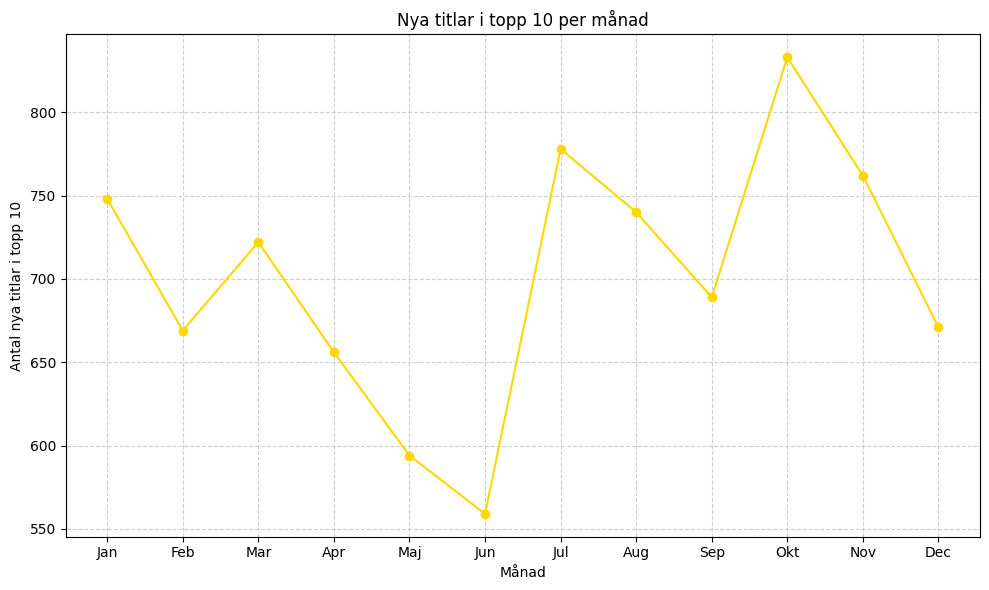

In [48]:
# Beräkna första gången varje titel dyker upp i topp 10, extrahera månad från veckodatumet
query = """
    SELECT 
        country_name,
        show_title,
        category,
        MIN(week) as first_week
    FROM nordic_weekly
    WHERE weekly_rank <= 10
    GROUP BY country_name, show_title, category
"""
first_appearance = duckdb.sql(query).df()
first_appearance['month'] = pd.to_datetime(first_appearance['first_week']).dt.month

# Räkna antal nya titlar per månad
monthly_new = first_appearance.groupby('month').size().reset_index(name='new_titles')
monthly_new = monthly_new.sort_values('month')
print(monthly_new)

plt.plot(monthly_new['month'], monthly_new['new_titles'], marker='o', linestyle='-', color='gold')
plt.xlabel('Månad')
plt.ylabel('Antal nya titlar i topp 10')
plt.title('Nya titlar i topp 10 per månad')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','Maj','Jun','Jul','Aug','Sep','Okt','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

4. Hur många veckor har en specifik titel varit i topp 10 i de nordiska länderna

  country_name  total_weeks
0      Denmark           16
1      Finland           15
2       Norway           15
3       Sweden           14
4      Iceland           13


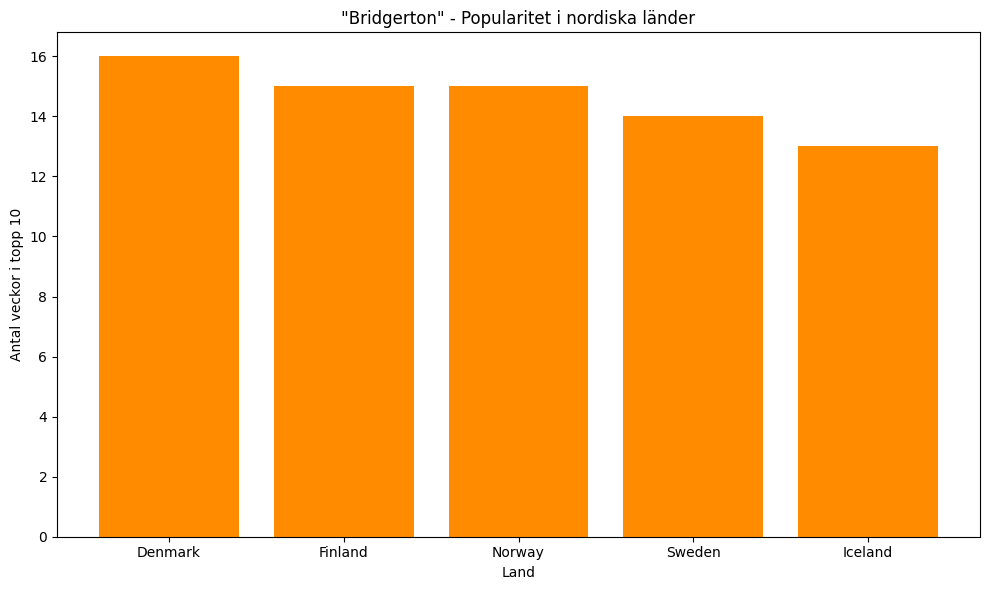

In [49]:
# Välj titel, till exempel "Bridgerton"
title = "Bridgerton"
# Visa hur många veckor den legat i topp 10 per land, MAX cumulative_weeks per land
query = f"""
    SELECT 
        country_name,
        MAX(cumulative_weeks_in_top_10) AS total_weeks
    FROM nordic_weekly
    WHERE lower(show_title) = lower('{title}')
      AND category = 'TV'
      AND country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
    GROUP BY country_name
    ORDER BY total_weeks DESC
"""
bridgerton_data = duckdb.sql(query).df()
print(bridgerton_data)

plt.bar(bridgerton_data['country_name'], bridgerton_data['total_weeks'], color='darkorange')
plt.xlabel('Land')
plt.ylabel('Antal veckor i topp 10')
plt.title(f'"{title}" - Popularitet i nordiska länder')
plt.tight_layout()
plt.show()

## Sammanfattning
Vad datan säger.
- *Film vs TV-serier*: Island är enda landet med mer film 52% än tv-serier 48%.
- *Gemensamma titlar*: Sverige och Danmark delar 1 513 titlar.
- *Långlivade titlar*: "Paw Patrol: The Movie" i Island 48 veckor och "KPop Demon Hunters" i Sverige/Danmark 36 veckor.
- *Totalt antal veckor*: Island har flest veckor i topp 10.
- *Säsongsmönster*: Oktober har flest veckor och april minst.